# MIMM OS Distribution

This notebook loads `patients_mimm.csv` and visualizes the distribution of `os_months` across all patients in MIMM.


In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

DATA_ROOT = Path('/Users/marcalbesa/Desktop/TFM/data/MIMM')
PATIENTS_PATH = DATA_ROOT / 'patients_mimm.csv'
TARGET_COL = 'os_months'

if not PATIENTS_PATH.is_file():
    raise FileNotFoundError(f'Could not find patients_mimm.csv at: {PATIENTS_PATH}')


## Load Patients Table

Load the patient-level table and keep only valid `os_months` values.


In [12]:
patients_df = pd.read_csv(PATIENTS_PATH)

required_cols = ['patient', TARGET_COL]
missing_cols = [col for col in required_cols if col not in patients_df.columns]
if missing_cols:
    raise ValueError(f'patients_mimm.csv is missing required columns: {missing_cols}')

os_df = patients_df[['patient', TARGET_COL]].copy()
os_df[TARGET_COL] = pd.to_numeric(os_df[TARGET_COL], errors='coerce')
os_df = os_df.dropna(subset=[TARGET_COL]).reset_index(drop=True)

print(f'Total patients with valid os_months: {len(os_df)}')
print(f'Min os_months: {os_df[TARGET_COL].min():.3f}')
print(f'Max os_months: {os_df[TARGET_COL].max():.3f}')
print(f'Mean os_months: {os_df[TARGET_COL].mean():.3f}')
print(f'Median os_months: {os_df[TARGET_COL].median():.3f}')
print()
print('=== os_months summary ===')
display(os_df[TARGET_COL].describe().to_frame(name=TARGET_COL))


Total patients with valid os_months: 281
Min os_months: 1.250
Max os_months: 118.270
Mean os_months: 16.767
Median os_months: 9.468

=== os_months summary ===


,os_months
count,281.000000
mean,16.767370
std,18.592004
min,1.250000
25%,4.767124
50%,9.468495
75%,22.586306
max,118.270000


## Plot Distribution

Histogram with mean and median lines, plus a boxplot to inspect spread and outliers.


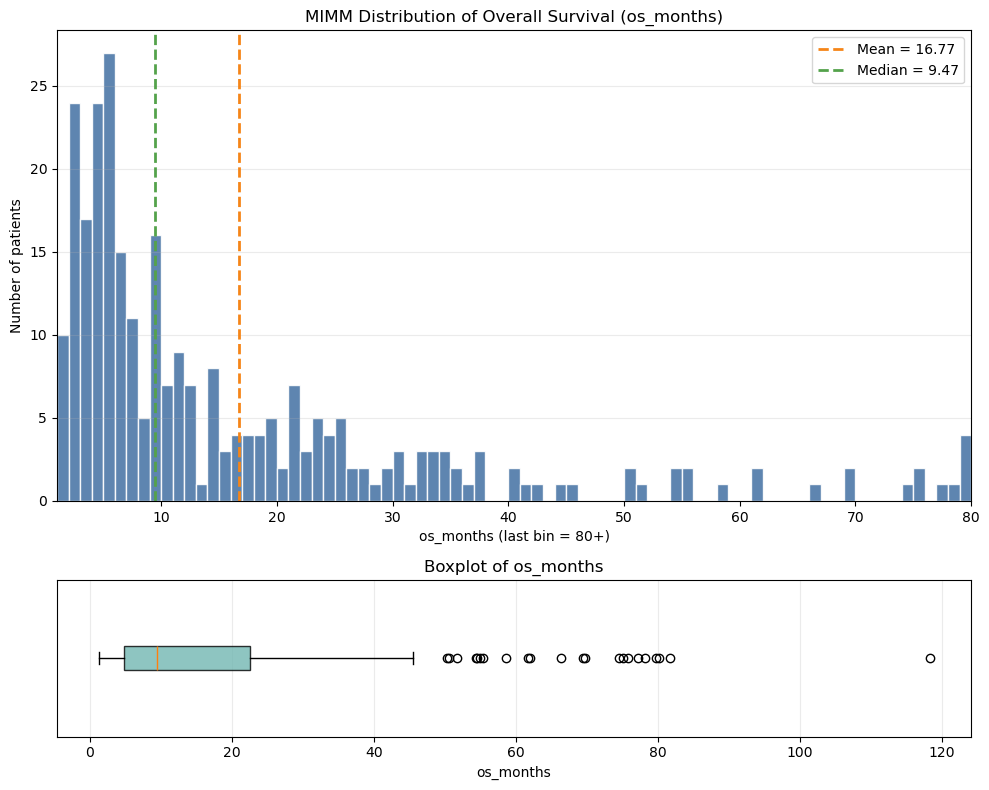

In [13]:
import matplotlib.pyplot as plt
values = os_df[TARGET_COL].to_numpy(dtype=float)
mean_value = float(np.mean(values))
median_value = float(np.median(values))
hist_cap = 80.0
hist_values = np.minimum(values, hist_cap)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]})

month_bins = np.arange(np.floor(values.min()), hist_cap + 1, 1.0)
axes[0].hist(hist_values, bins=month_bins, color='#4C78A8', edgecolor='white', alpha=0.9)
axes[0].set_xlim(np.floor(values.min()), hist_cap)
axes[0].axvline(mean_value, color='#F58518', linestyle='--', linewidth=2, label=f'Mean = {mean_value:.2f}')
axes[0].axvline(median_value, color='#54A24B', linestyle='--', linewidth=2, label=f'Median = {median_value:.2f}')
axes[0].set_title('MIMM Distribution of Overall Survival (os_months)')
axes[0].set_xlabel('os_months (last bin = 80+)')
axes[0].set_ylabel('Number of patients')
axes[0].grid(axis='y', alpha=0.25)
axes[0].legend()

axes[1].boxplot(values, vert=False, patch_artist=True, boxprops={'facecolor': '#72B7B2', 'alpha': 0.8})
axes[1].set_xlabel('os_months')
axes[1].set_yticks([])
axes[1].set_title('Boxplot of os_months')
axes[1].grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.show()


## Export Reduced Patients Table

Remove patients with `8 < os_months < 10` and save the filtered table as `patients_mimm_reduced.csv` in the same dataset directory.


In [14]:
REDUCED_PATIENTS_PATH = DATA_ROOT / 'patients_mimm_reduced.csv'

mask_to_remove = (os_df[TARGET_COL] > 8.0) & (os_df[TARGET_COL] < 10.0)
patients_to_remove = set(os_df.loc[mask_to_remove, 'patient'])
reduced_patients_df = patients_df.loc[~patients_df['patient'].isin(patients_to_remove)].copy()
reduced_patients_df.to_csv(REDUCED_PATIENTS_PATH, index=False)

print(f'Original rows: {len(patients_df)}')
print(f'Removed rows: {len(patients_df) - len(reduced_patients_df)}')
print(f'Reduced rows: {len(reduced_patients_df)}')
print(f'Saved reduced dataset to: {REDUCED_PATIENTS_PATH}')


Original rows: 281
Removed rows: 21
Reduced rows: 260
Saved reduced dataset to: /Users/marcalbesa/Desktop/TFM/data/MIMM/patients_mimm_reduced.csv
